# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [3]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=43000 sha256=18ecd51d1dc5bad0d357e0ebfdd74a45f5649ee586ff44acfc2d6d87ef4c8e75
  Stored in directory: c:\users\anders\appdata\local\pip\cache\wheels\43\6a\e8\108096f3a70f5a0d317dc4e7db185e556adf1f7e1b50c2e8b4
Successfully built assertpy
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!tar -xJf waf-urls.tar.xz

In [1]:
print('j')

j


## 1. Data Loading

In [87]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [88]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [  1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded_text = text + end_symbol
    for i in range(n-1):
        padded_text = start_symbol + padded_text + end_symbol
    # print(len(text))
    for i in range(len(text)+n):
        yield padded_text[i:i+n]
    # raise NotImplementedError
# iter_ngrams('/text', n=3)
# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [ ]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            
            ## [  2.1 ] Count N-gram occurrences
            if ngram not in ngram_count.keys():
                ngram_count[ngram] = 1
            else: 
                ngram_count[ngram] +=1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    
    for ngram, count in tqdm(ngram_count.items()):
        ## [ 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        
        if count>= rare_threshold:
            n2i[ngram] = n_rare
            i2n.append(ngram)
            n_rare +=1
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<?, ?it/s]


Building mapping...


100%|██████████| 15/15 [00:00<?, ?it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [ ]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ 3.1 ] Get N-gram index (unknown_idx if not found)
            
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            ## [  3.2 ] Update co-occurrence for prev neighbors in window
            start = max(0, len(prev_indices)-window_size)
            for prev_idx in prev_indices[start:]:
                co_matrix[prev_idx, idx] +=1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [  3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i, 0] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i, 0]
    
    return co_matrix




from scipy.sparse import csr_matrix
from tqdm import tqdm
# FYI, I created this faster version using an LLM
# The original version with dok_matrix is very slow due to Python loops and dictionary overhead.
def build_cooccurrence_matrix_fast(urls, n, n2i_mapping, window_size):
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    
    rows = []
    cols = []

    print(f'Collecting co-occurrence pairs...')
    for url in tqdm(urls):
        # Pre-convert URL to indices to avoid repeated dict lookups
        indices = [n2i_mapping.get(ngram, unknown_idx) for ngram in iter_ngrams(url, n)]
        
        for i, idx in enumerate(indices):
            # Look back within window_size
            start = max(0, i - window_size)
            for j in range(start, i):
                prev_idx = indices[j]
                rows.append(prev_idx)
                cols.append(idx)

    print('Building Sparse Matrix...')
    # Scipy automatically sums duplicates at the same (row, col)
    # This creates a CSR matrix: weights are all 1s initially
    ones = np.ones(len(rows), dtype=np.float32)
    co_matrix = csr_matrix((ones, (rows, cols)), shape=(n_ngram+1, n_ngram+1))

    print('Normalizing...')
    # Vectorized normalization (no loops!)
    row_sums = np.array(co_matrix.sum(axis=1)).flatten()
    # Replace zeros with 1 to avoid division by zero errors
    row_sums[row_sums == 0] = 1.0
    
    # Efficiently divide each row by its sum
    # (Multiply by diagonal of reciprocals)
    from scipy.sparse import diags
    inv_row_sums = diags(1.0 / row_sums)
    co_matrix = inv_row_sums @ co_matrix

    return co_matrix

In [ ]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 26667.66it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2087068.10it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [06:43<00:00, 90.03it/s] 


Normalizing...


100%|██████████| 1317180/1317180 [00:47<00:00, 27585.17it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [92]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter =20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [93]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [  5.1 ] Pad URL to padded_len
        diff = padded_len - len(url)
        if diff > 0:
            for _ in range(diff):
                url +=pad_symbol
        
        ## [  5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [95]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [ ]:
import torch.nn.functional as F

class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        embedding_weights = torch.from_numpy(embedding_weights).float()
        ## [  6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=True)

        ## [  6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=20, kernel_size=5, padding=2)
        # conv2: 20 -> 40, kernel=5, padding=2
        self.conv2 = nn.Conv1d(in_channels=20, out_channels=40, kernel_size=5, padding=2)
        # conv3: 40 -> 80, kernel=5, padding=2
        self.conv3 = nn.Conv1d(in_channels=40, out_channels=80, kernel_size=5, padding=2)
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
    
        
        ## [ 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(in_features=160, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=1)
        # raise NotImplementedError
    
    def forward(self, x):
        ## [  6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x_emb = self.embedding(x)
        x_perm = torch.permute(x_emb, (0, 2, 1))
        x_c1 = self.pool1(F.relu(self.conv1(x_perm)))
        x_c2 = self.pool2(F.relu(self.conv2(x_c1)))
        x_c3 = self.pool3(F.relu(self.conv3(x_c2)))
        x_flat = torch.flatten(x_c3, 1)
        x_fc1 = F.relu(self.fc1(x_flat))
        x_out = F.sigmoid(self.fc2(x_fc1))
        return x_out
        
        # raise NotImplementedError

In [105]:
print(len(n2i_urls))
print(type(n2i_urls))
print(embedding_svd.shape)

82844
<class 'dict'>
(82845, 10)


In [111]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 50

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [112]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [  7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        pred = model(x).squeeze()
        
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((pred>0.5)==y).sum().item()
        total += len(y)
        
        # raise NotImplementedError
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x).squeeze()
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [113]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7288, Val Acc=0.8762
Epoch 2: Train Acc=0.8864, Val Acc=0.8904
Epoch 3: Train Acc=0.9103, Val Acc=0.9195
Epoch 4: Train Acc=0.9236, Val Acc=0.9254
Epoch 5: Train Acc=0.9279, Val Acc=0.9329
Epoch 6: Train Acc=0.9314, Val Acc=0.9335
Epoch 7: Train Acc=0.9401, Val Acc=0.9329
Epoch 8: Train Acc=0.9408, Val Acc=0.9410
Epoch 9: Train Acc=0.9457, Val Acc=0.9465
Epoch 10: Train Acc=0.9452, Val Acc=0.9348
Epoch 11: Train Acc=0.9478, Val Acc=0.9491
Epoch 12: Train Acc=0.9502, Val Acc=0.9444
Epoch 13: Train Acc=0.9510, Val Acc=0.9476
Epoch 14: Train Acc=0.9521, Val Acc=0.9537
Epoch 15: Train Acc=0.9539, Val Acc=0.9511
Epoch 16: Train Acc=0.9553, Val Acc=0.9528
Epoch 17: Train Acc=0.9562, Val Acc=0.9536
Epoch 18: Train Acc=0.9578, Val Acc=0.9533
Epoch 19: Train Acc=0.9589, Val Acc=0.9550
Epoch 20: Train Acc=0.9606, Val Acc=0.9595
Epoch 21: Train Acc=0.9614, Val Acc=0.9565
Epoch 22: Train Acc=0.9621, Val Acc=0.9550
Epoch 23: Train Acc=0.9631, Val Acc=0.9602
Epoch 24: Train Acc=

## 6. Evaluation

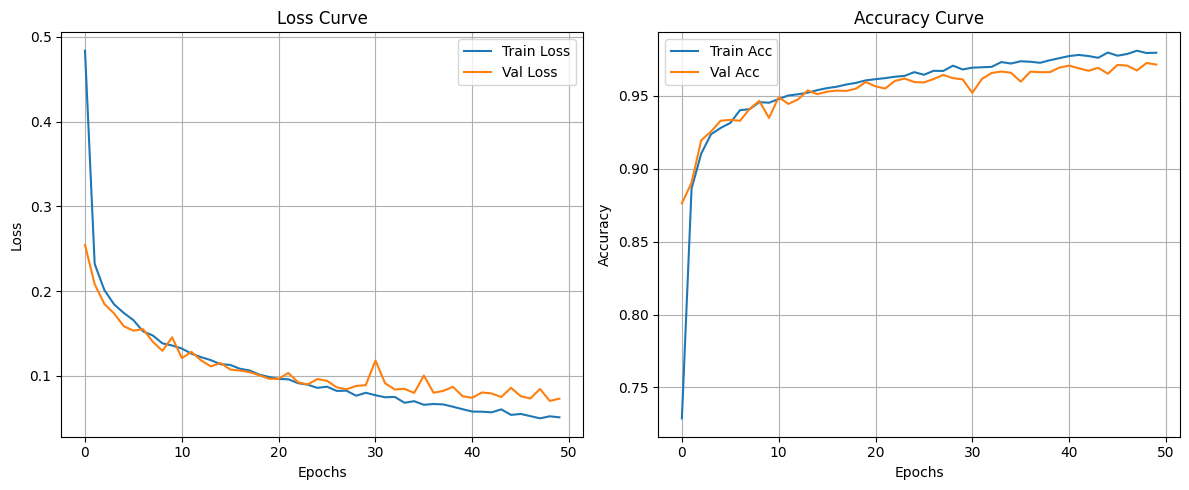

In [114]:
import matplotlib.pyplot as plt

## [  8 ] Plot loss and accuracy curves


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(history['acc'], label='Train Acc')
ax[1].plot(history['val_acc'], label='Val Acc')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()



In [115]:
from sklearn.metrics import confusion_matrix, classification_report

## [ 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report

test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
y_true, y_pred = [], []

def evaluate_test(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    y_true, y_pred_labels = [], []
    
    with torch.no_grad():
        for x, y in loader:

            x, y = x.to(device).long(), y.to(device).float()
            
            out = model(x).squeeze()
            
            total_loss += criterion(out, y).item() * len(y)
            preds = (out > 0.5).float()
            correct += (preds == y).sum().item()
            total += len(y)

            y_true.extend(y.cpu().numpy())
            y_pred_labels.extend(preds.cpu().numpy())
            
    return total_loss / total, correct / total, y_true, y_pred_labels

test_loss, test_acc, y_true, y_pred = evaluate_test(model, test_loader, criterion)

print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
print("-" * 30)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malicious']))

Test Loss: 0.0853, Test Acc: 0.9699
------------------------------
Confusion Matrix:
[[6928  215]
 [ 149 4818]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97      7143
   Malicious       0.96      0.97      0.96      4967

    accuracy                           0.97     12110
   macro avg       0.97      0.97      0.97     12110
weighted avg       0.97      0.97      0.97     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

In this case, lower loss does indicate higher accuracy. A well designed loss function should lead to increases in model performance (in this case, performance is modelled by accuracy)

**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

In [ ]:
N = 4
WINDOW_SIZE = 50

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter =20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 50

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn-50.pt')

test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
test_loss, test_acc, y_true, y_pred = evaluate_test(model, test_loader, criterion)

print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
print("-" * 30)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malicious']))

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 25714.75it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 1787522.66it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


  5%|▌         | 1879/36327 [02:00<41:50, 13.72it/s]

**Your Answer:**



## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`